In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set environment variables
import os


os.environ["SCAL_TYPE"] = "complex"
os.environ["PRECISION"] = "double"
os.environ["MY_NUMBA_TARGET"] = "numba"
 
 
# Add cle_fun to PYTHON_PATH
import sys
sys.path.append("../../clonscal")

In [2]:
import numpy as np

lamb = 2
sigma_abs = 3

# number of different phases
start_angle = 0.01
stop_angle = np.pi
num = 1
angles = np.linspace(start_angle, stop_angle, num, endpoint=False)
angles = np.array([1/8, 2/8, 3/8, 7/16, 17/32])*2*np.pi
sigma_vals = sigma_abs*(np.cos(angles) + 1j*np.sin(angles))
sigma_vals = [-1+4j]

mass_modification = 2.5
pullback = 200

In [3]:
import numpy as np
from simulation.config import Config
from simulation.cl_simulation import ComplexLangevinSimulation
from src.obs_kernels import (
    n_moment_kernel, 
    dse_n_moment_kernel,
    abs_drift
)
from tqdm import tqdm
from simulation.gpu_handler import GPU_handler
from src.numba_target import use_cuda
import src.scal as scal
from src.utils import (
    gaussian_modified_density_drift_kernel_rotated, 
    update_histogram_complex, 
    update_histogram_real,
    mexican_hat_kernel_real, 
    noise_kernel_rotated
)

from src.numba_target import my_act_parallel_loop

if use_cuda: from numba import cuda

steps = int(5e5)
trajs = int(1e5)

histograms_p = []
histograms_u = []
for idx_sig, sigma in enumerate(sigma_vals):
    label = rf"$Re (\sigma)={{{np.round(sigma.real, 2)}}} \quad Im (\sigma)={{{np.round(sigma.imag, 2)}}}$"

    
    config = Config(dt = 1e-4, trajs = trajs, dims = [1], mass_real = sigma, interaction = lamb, 
                    ada_step = True, drift_kernel=gaussian_modified_density_drift_kernel_rotated,
                    noise_kernel=noise_kernel_rotated,
                    mass_modification=mass_modification, pullback=pullback)
    sim = ComplexLangevinSimulation(config)
    
    bins = 1000  # Number of bins
    hist_p = np.zeros((bins, bins), dtype=scal.SCAL_TYPE_REAL)
    hist_u = np.zeros(bins, dtype=scal.SCAL_TYPE_REAL)
    if use_cuda: hist_p = cuda.to_device(hist_p); cuda.to_device(hist_p)

    sim.register_observable('1_moment', obs_kernel=n_moment_kernel, const_param={'order': 1}, 
                        langevin_history=False, thermal_time=0.5, auto_corr=0.5)
    sim.register_observable('2_moment', obs_kernel=n_moment_kernel, const_param={'order': 2}, 
                    langevin_history=False, thermal_time=0.5, auto_corr=0.5)
    sim.register_observable('dse_1_moment', obs_kernel=dse_n_moment_kernel, const_param={'order': 1}, 
                    langevin_history=False, thermal_time=0.5, auto_corr=0.5)
    sim.register_observable('abs_drift', obs_kernel=abs_drift, 
                            langevin_history=False, thermal_time=0.5, auto_corr=0.5,dtype=scal.SCAL_TYPE_REAL)
    
    # sim.register_observable('2_moment', obs_kernel=n_moment_kernel, const_param={'order': 2}, 
    #                         langevin_history=False, thermal_time=0.5, auto_corr=0.5)
    # sim.register_observable('3_moment', obs_kernel=n_moment_kernel, const_param={'order': 3}, 
    #                         langevin_history=False, thermal_time=0.5, auto_corr=0.5)
    # sim.register_observable('4_moment', obs_kernel=n_moment_kernel, const_param={'order': 4}, 
    #                         langevin_history=False, thermal_time=0.5, auto_corr=0.5)
    # sim.register_observable('5_moment', obs_kernel=n_moment_kernel, const_param={'order': 5}, 
    #                         langevin_history=False, thermal_time=0.5, auto_corr=0.5)

    # sim.register_observable('dse_1_moment', obs_kernel=dse_n_moment_kernel, const_param={'order': 1}, 
    #                         langevin_history=False, thermal_time=0.5, auto_corr=0.5)
    # sim.register_observable('dse_2_moment', obs_kernel=dse_n_moment_kernel, const_param={'order': 2}, 
    #                         langevin_history=False, thermal_time=0.5, auto_corr=0.5)
    # sim.register_observable('dse_3_moment', obs_kernel=dse_n_moment_kernel, const_param={'order': 3}, 
    #                         langevin_history=False, thermal_time=0.5, auto_corr=0.5)
    # sim.register_observable('dse_4_moment', obs_kernel=dse_n_moment_kernel, const_param={'order': 4}, 
    #                         langevin_history=False, thermal_time=0.5, auto_corr=0.5)
    # sim.register_observable('dse_5_moment', obs_kernel=dse_n_moment_kernel, const_param={'order': 5}, 
    #                         langevin_history=False, thermal_time=0.5, auto_corr=0.5)

    gpu_handler = GPU_handler(sim)
    if use_cuda: gpu_handler.to_device()

    for _ in tqdm(range(steps)):
        sim.step()
        for name, tr in sim.trackers.items():
            tr.mark_equilibrated_trajs()
            tr.compute()

        p_tracker = sim.trackers["1_moment"]
        u_tracker = sim.trackers["abs_drift"]
        my_act_parallel_loop(update_histogram_complex, p_tracker.equilibrated_trajs, trajs, p_tracker.result, hist_p, bins, -10, 10, -10, 10)
        my_act_parallel_loop(update_histogram_real, u_tracker.equilibrated_trajs, trajs, u_tracker.result, hist_u, bins, 0.001, 1000)
        if use_cuda: cuda.synchronize()

    sim.finish()
    if use_cuda: gpu_handler.to_host()
    histograms_p.append(hist_p)
    histograms_u.append(hist_u)

Using double precision
Using C^1
Using Numba


100%|██████████| 500000/500000 [20:20<00:00, 409.59it/s]


In [4]:
# rebin
import numpy as np

def rebin_2d(hist, factor_x, factor_y):
    """
    Rebins a 2D histogram by summing over blocks of (factor_x, factor_y) bins.
    
    Parameters:
        hist (np.ndarray): The original 2D histogram (bins_x, bins_y).
        factor_x (int): Rebinning factor along x (real).
        factor_y (int): Rebinning factor along y (imag).

    Returns:
        np.ndarray: The rebinned histogram.
    """
    bins_x, bins_y = hist.shape
    new_bins_x = bins_x // factor_x
    new_bins_y = bins_y // factor_y
    
    # Ensure dimensions are divisible by factors (trim if necessary)
    hist = hist[:new_bins_x * factor_x, :new_bins_y * factor_y]
    
    # Reshape and sum over blocks
    rebinned_hist = hist.reshape(new_bins_x, factor_x, new_bins_y, factor_y).sum(axis=(1, 3))
    
    return rebinned_hist

def rebin_1d(hist, factor):
    """
    Rebins a 1D histogram by summing over blocks of `factor` bins.

    Parameters:
        hist (np.ndarray): The original 1D histogram (array of bin counts).
        factor (int): The number of adjacent bins to merge into one.

    Returns:
        np.ndarray: The rebinned histogram.
    """
    bins = len(hist)
    new_bins = bins // factor  # Compute the new number of bins

    # Trim the histogram if needed to ensure divisibility
    hist = hist[:new_bins * factor]

    # Reshape and sum over blocks
    rebinned_hist = hist.reshape(new_bins, factor).sum(axis=1)
    
    return rebinned_hist


In [5]:
# solve_floweq
from scipy.integrate import solve_ivp

def stop_event(t, z, *args, **kwargs):
    x, y = z
    return max(x, y) - 10  # Triggers when either x or y reaches 10

stop_event.terminal = True

def solve_floweq(flow_equation, crit_point, epsilon = 0.001, t_span = (0, 100), t_points=10, events = None, **kwargs):
    sigma = kwargs.get("sigma", 5*np.exp(1j*np.pi*3/4)) 
    lamb = kwargs.get("lamb", 1) 
    pullback = kwargs.get("pullback", 1) 
    mass_modification = kwargs.get("mass_modification", 5)

    t_eval = np.linspace(t_span[0], t_span[1], t_points)
    sol = []
    flow_times = []
    
    directions_num = 4
    angles = np.linspace(0+0.01, 2*np.pi+0.01, directions_num, endpoint=False)
    perturbations = epsilon * np.exp(1j * angles)

    for perturb in perturbations:
        z0 = crit_point + perturb
        z0 = [np.real(crit_point + perturb), np.imag(crit_point + perturb)]

        solution = solve_ivp(flow_equation, t_span, y0 = z0, args = (sigma, lamb, pullback, mass_modification), t_eval=t_eval, method="BDF", events=stop_event)
        sol.append(solution.y[0] + 1j * solution.y[1])
        flow_times.append(solution.t)
    return sol, flow_times


In [6]:
# drift func

# gaussian mod
@np.vectorize
def drift_func(z, sigma, lamb, pullback, mass_modification):
    action = sigma/2*z**2+lamb/4*z**4
    mod = -mass_modification*z**2/2
    action_mod = action + mod
    drift = sigma*z+lamb*z**3

    if np.real(action_mod) < 0:
        return drift-pullback*(drift-mass_modification*z)*np.exp(action_mod) / (1+pullback*np.exp(action_mod))
    else: 
        return drift-pullback*(drift-mass_modification*z) / (np.exp(-action_mod)+pullback)

def flow_equation_stable(t, z, *kwargs):
    z_real, z_imag = z
    z_complex = z_real+1j*z_imag
    flow = np.conj(drift_func(z_complex, *kwargs))
    return [np.real(flow), np.imag(flow)]

def flow_equation_unstable(t, z, *kwargs):
    z_real, z_imag = z
    z_complex = z_real+1j*z_imag
    flow = -np.conj(drift_func(z_complex, *kwargs))
    return [np.real(flow), np.imag(flow)]

In [7]:
# root finder

def F_real(z_real, sigma, lamb, pullback, mass_modification):
    z = z_real[0] + 1j * z_real[1]
    action = sigma/2*z**2+lamb/4*z**4
    mod = -mass_modification*z**2/2
    action_mod = action + mod
    drift = sigma*z+lamb*z**3

    if np.real(action_mod) < 0:
        out = drift-pullback*(drift-mass_modification*z)*np.exp(action_mod) / (1+pullback*np.exp(action_mod))
    else: 
        out =  drift-pullback*(drift-mass_modification*z) / (np.exp(-action_mod)+pullback)
    return np.array([out.real, out.imag])


from scipy.optimize import root as root_scipy

def find_roots(guess, sigma, lamb, pullback, mass_modification):
    sol = root_scipy(F_real, guess, method='hybr', args=(sigma, lamb, pullback, mass_modification))
    if sol.success:
        root_found = sol.x[0] + 1j * sol.x[1]
        return root_found
    return 0

In [8]:
# action
@np.vectorize
def action_mod(z, sigma, lamb, pullback, mass_modification):
    if np.real(np.log10(pullback)+sigma/2*z**2 + lamb/4*z**4 -mass_modification/2*z**2) > 100:
        return sigma/2*z**2 + lamb/4*z**4-np.log(pullback)*(sigma/2*z**2 + lamb/4*z**4 - mass_modification/2*z**2)  
    return sigma/2*z**2 + lamb/4*z**4-np.log(1+pullback*np.exp(sigma/2*z**2 + lamb/4*z**4 - mass_modification/2*z**2))

@np.vectorize
def action_unmod(z, sigma, lamb):
    return sigma/2*z**2+lamb/4*z**4

@np.vectorize
def drift_unmod(z, sigma, lamb):
    return sigma*z+lamb*z**3

In [9]:
# thimble length
def cumulative_curve_length(z):
    """Compute the cumulative length of a curve given by a NumPy array of complex numbers."""
    dz = np.diff(z)  # Differences between consecutive points
    segment_lengths = np.abs(dz)  # Euclidean distance (modulus of complex numbers)
    cumulative_lengths = np.concatenate(([0], np.cumsum(segment_lengths)))  # Cumulative sum
    return cumulative_lengths

In [10]:
def find_min_max(hist, bare_min, bare_max):
    bins = hist.shape[0]
    for idx, val in enumerate(hist[0,:]):
        if val!=0: x_min = idx; break

    for idx, val in enumerate(np.flip(hist, axis=1)[0,:]):
        if val!=0: x_max = idx; break

    for idx, val in enumerate(hist[:,0]):
        if val!=0: y_min = idx; break

    for idx, val in enumerate(np.flip(hist, axis=1)[:,0]):
        if val!=0: y_max = idx; break
    return (x_min, x_max, y_min, y_max)


(1000, 1000)


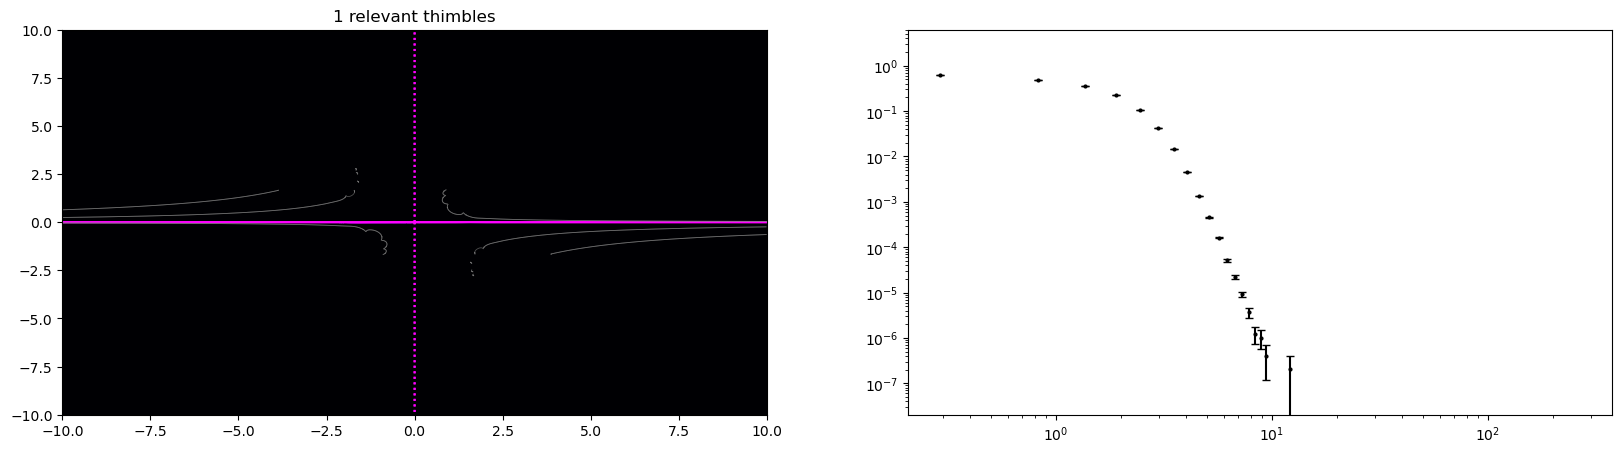

In [11]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

for hist, sigma in zip(histograms_p, sigma_vals):

    fig, ax = plt.subplots(1, 2, figsize=(20, 5))
    print(hist.shape)
    # Histograms
    if use_cuda: 
        hist_host = hist.copy_to_host()
    else: hist_host = rebin_2d(hist, 1, 1)

    hist_host
    min_real, max_real = -5, 5
    min_imag, max_imag = -1, 1

    # Define bin edges for the plot
    real_bins = np.linspace(min_real, max_real, bins)
    imag_bins = np.linspace(min_imag, max_imag, bins)

    real_grid, imag_grid = np.meshgrid(real_bins, imag_bins, indexing='ij')
    U_values = np.abs(drift_unmod(real_grid + 1j * imag_grid, sigma, lamb))
    U_min, U_max = U_values.min(), U_values.max()

    U_bins = np.linspace(U_min, U_max, 500)
    U_centers = 0.5 * (U_bins[:-1] + U_bins[1:])  # Bin centers
    rho_u = np.histogram(U_values.flatten(), bins = U_bins, weights = hist.flatten(), density=True)
    counts, U_edges = np.histogram(U_values.flatten(), bins=U_bins, weights=hist.flatten(), density=False)
    rho_u_error = np.sqrt(counts) / (np.sum(hist) * np.diff(U_bins))
    
    ax[1].errorbar(U_centers, rho_u[0], yerr=rho_u_error, fmt='o', color='black', markersize=2, capsize=3)
    ax[1].set_ylim(rho_u[0][rho_u[0]!=0].min()/10, rho_u[0][rho_u[0]!=0].max()*10)
    ax[1].set_yscale("log")
    ax[1].set_xscale("log")
    # Create the figure and axis
    ax[0].imshow(np.log10(hist_host.T+1e-6), origin='lower', aspect='auto', extent=[-10, 10, -10, 10], cmap='inferno')


    # Thimbles
    x_vals = np.linspace(-5, 5, 10)  # Real part of z
    y_vals = np.linspace(-5, 5, 10)  # Imaginary part of z
    initial_guesses = [(x, y) for x in x_vals for y in y_vals]
    roots = []
    for guess in initial_guesses:
        root_found = find_roots(guess, sigma, lamb, pullback, mass_modification)
        if not any(np.isclose(root_found, r, atol=1e-6) for r in roots):
            roots.append(root_found)

    cols_idx = np.linspace(0, 1, len(roots))
    num_relevant = 0
    for roo, col in zip(roots,  cm.rainbow(cols_idx)):
        # print(f"drift zero: {roo}")
        solutions, flow_times = solve_floweq(flow_equation_unstable, crit_point=roo, t_span = (0, 100), t_points=100000, 
                                sigma = sigma, lamb=lamb, pullback=pullback, mass_modification=mass_modification)
                
        relevant = False
        conc_sol = np.concatenate(solutions, axis = 0)
        if any(conc_sol.imag>0) and any(conc_sol.imag<0): relevant = True; num_relevant += 1

        for sol in solutions:
            if relevant:
                ax[0].plot(sol.real, sol.imag, color = "magenta", ls = ':')  # Set transparency for better visibility
            else: pass
                # ax[0].plot(sol.real, sol.imag, color = 'gray', ls = ':')  # Set transparency for better visibility

        # stable
        solutions, flow_times = solve_floweq(flow_equation_stable, crit_point=roo, t_span = (0, 100), t_points=100000, sigma = sigma, lamb=lamb, pullback=pullback, mass_modification=mass_modification)
        for sol, fl_time in zip(solutions, flow_times):
            # ax[1].set_title(len(solutions))
            if relevant:
                # print(f"minimal action: {np.min(np.imag(action_mod(sol, sigma, lamb, pullback, mass_modification)))}")
                # print(f"maximal action: {np.max(np.imag(action_mod(sol, sigma, lamb, pullback, mass_modification)))}")
                ax[0].plot(sol.real, sol.imag, color = "magenta", ls = "solid")
                # ax[1].scatter(fl_time,(np.imag(action_mod(sol, sigma, lamb, pullback, mass_modification))), s=1, color = col)
            else:
                ax[0].plot(sol.real, sol.imag, color = 'gray', ls = "solid", alpha=0.6, lw = 0.6)  # Set transparency for better visibility
        ax[0].set_xlim(-10, 10)
        ax[0].set_ylim(-10, 10)
        ax[0].set_title(f"{num_relevant} relevant thimbles")

(1000, 1000)


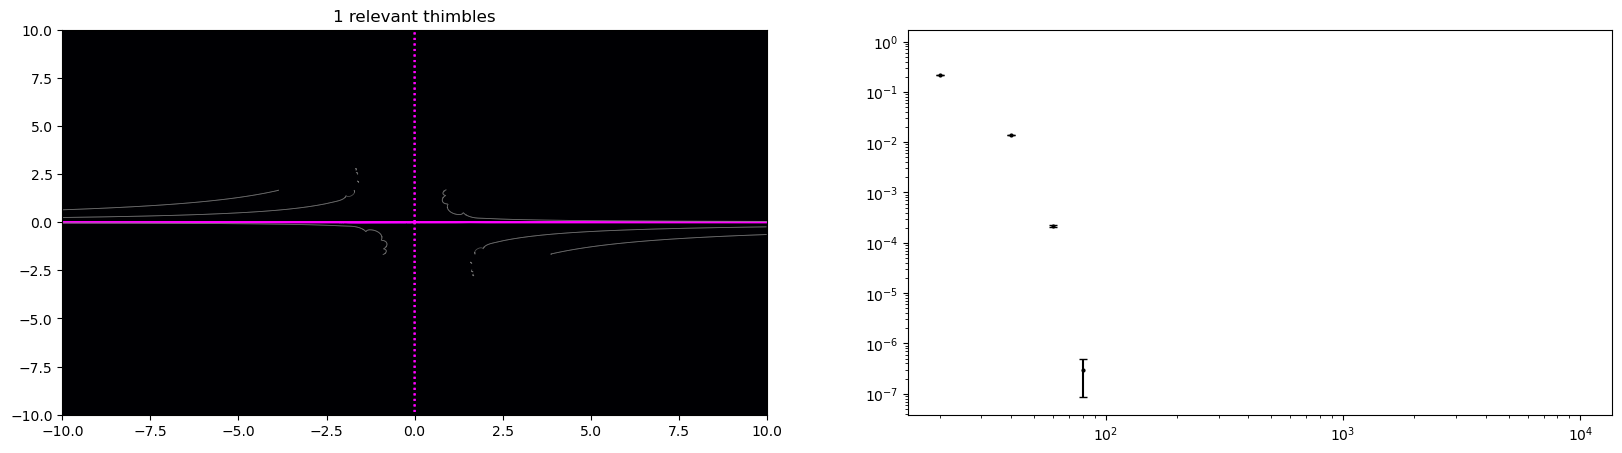

In [12]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

for hist_p, hist_u, sigma in zip(histograms_p, histograms_u, sigma_vals):

    fig, ax = plt.subplots(1, 2, figsize=(20, 5))
    print(hist.shape)
    # Histograms
    if use_cuda: 
        hist_host = hist.copy_to_host()
    else: hist_host = rebin_2d(hist, 1, 1)

    # hist_host
    # min_real, max_real = -5, 5
    # min_imag, max_imag = -1, 1

    # # Define bin edges for the plot
    # real_bins = np.linspace(min_real, max_real, bins)
    # imag_bins = np.linspace(min_imag, max_imag, bins)

    # real_grid, imag_grid = np.meshgrid(real_bins, imag_bins, indexing='ij')
    # U_values = np.abs(drift_unmod(real_grid + 1j * imag_grid, sigma, lamb))

    # rho_u = np.histogram(U_values.flatten(), bins = U_bins, weights = hist.flatten(), density=True)
    # counts, U_edges = np.histogram(U_values.flatten(), bins=U_bins, weights=hist.flatten(), density=False)
    # rho_u_error = np.sqrt(counts) / (np.sum(hist) * np.diff(U_bins))
    
    # ax[1].errorbar(U_centers, rho_u[0], yerr=rho_u_error, fmt='o', color='black', markersize=2, capsize=3)
    # ax[1].set_ylim(rho_u[0][rho_u[0]!=0].min()/10, rho_u[0][rho_u[0]!=0].max()*10)
    hist_u = rebin_1d(hist_u,2)
    hist_u_norm = hist_u / np.sum(hist_u)

# Compute relative errors (Poisson errors scaled by total count)
    errors = np.sqrt(hist_u) / np.sum(hist_u)  # Normalize errors

    U_min, U_max = 0, 1e4
    U_bins = np.linspace(U_min, U_max, len(hist_u_norm))
    U_centers = 0.5 * (U_bins[:-1] + U_bins[1:])  # Bin centers
    ax[1].errorbar(U_bins, hist_u_norm, yerr=errors, fmt='o', color='black', markersize=2, capsize=3)
    ax[1].set_yscale("log")
    ax[1].set_xscale("log")
    # Create the figure and axis
    ax[0].imshow(np.log10(hist_host.T+1e-6), origin='lower', aspect='auto', extent=[-10, 10, -10, 10], cmap='inferno')


    # Thimbles
    x_vals = np.linspace(-5, 5, 10)  # Real part of z
    y_vals = np.linspace(-5, 5, 10)  # Imaginary part of z
    initial_guesses = [(x, y) for x in x_vals for y in y_vals]
    roots = []
    for guess in initial_guesses:
        root_found = find_roots(guess,sigma = sigma, lamb=lamb, pullback=pullback, mass_modification=mass_modification)
        if not any(np.isclose(root_found, r, atol=1e-6) for r in roots):
            roots.append(root_found)

    cols_idx = np.linspace(0, 1, len(roots))
    num_relevant = 0
    for roo, col in zip(roots,  cm.rainbow(cols_idx)):
        # print(f"drift zero: {roo}")
        solutions, flow_times = solve_floweq(flow_equation_unstable, crit_point=roo, t_span = (0, 100), t_points=100000, 
                                sigma = sigma, lamb=lamb, pullback=pullback, mass_modification=mass_modification)
                
        relevant = False
        conc_sol = np.concatenate(solutions, axis = 0)
        if any(conc_sol.imag>0) and any(conc_sol.imag<0): relevant = True; num_relevant += 1

        for sol in solutions:
            if relevant:
                ax[0].plot(sol.real, sol.imag, color = "magenta", ls = ':')  # Set transparency for better visibility
            else: pass
                # ax[0].plot(sol.real, sol.imag, color = 'gray', ls = ':')  # Set transparency for better visibility

        # stable
        solutions, flow_times = solve_floweq(flow_equation_stable, crit_point=roo, t_span = (0, 100), t_points=100000, sigma = sigma, lamb=lamb, pullback=pullback, mass_modification=mass_modification)
        for sol, fl_time in zip(solutions, flow_times):
            # ax[1].set_title(len(solutions))
            if relevant:
                # print(f"minimal action: {np.min(np.imag(action_mod(sol, sigma, lamb, pullback, mass_modification)))}")
                # print(f"maximal action: {np.max(np.imag(action_mod(sol, sigma, lamb, pullback, mass_modification)))}")
                ax[0].plot(sol.real, sol.imag, color = "magenta", ls = "solid")
                # ax[1].scatter(fl_time,(np.imag(action_mod(sol, sigma, lamb, pullback, mass_modification))), s=1, color = col)
            else:
                ax[0].plot(sol.real, sol.imag, color = 'gray', ls = "solid", alpha=0.6, lw = 0.6)  # Set transparency for better visibility
        ax[0].set_xlim(-10, 10)
        ax[0].set_ylim(-10, 10)
        ax[0].set_title(f"{num_relevant} relevant thimbles")

In [13]:
def calculate_stats_complex(rolling_mean, rolling_sqr_mean, counter):
    """
    Calculate mean and SEM for complex numbers.
    
    Parameters:
    rolling_mean (np.array): Single-element array containing the rolling sum of complex values.
    rolling_sqr_mean (np.array): Single-element array containing the rolling sum of squared magnitudes of complex values.
    counter (np.array): Single-element array containing the number of values.
    
    Returns:
    tuple: (mean, sem_real, sem_imag), where:
        - mean is the complex mean,
        - sem_real is the SEM for the real part,
        - sem_imag is the SEM for the imaginary part.
    """
    if counter == 0:
        raise ValueError("Counter cannot be zero to avoid division by zero.")
    
    # Extract real and imaginary parts
    rolling_mean_real = rolling_mean.real
    rolling_mean_imag = rolling_mean.imag
    
    # Mean calculation
    mean_real = rolling_mean_real / counter
    mean_imag = rolling_mean_imag / counter
    
    # Variance for real part
    rolling_sqr_mean_real = rolling_sqr_mean
    variance = (rolling_sqr_mean_real / counter) - mean_real**2 - mean_imag**2
    variance = max(variance, 0)
        
    # Standard error of the mean (SEM)
    sem = np.sqrt(variance / counter)
    
    # Return complex mean and SEM for real and imaginary parts
    mean = mean_real + 1j * mean_imag
    return mean, sem


In [14]:
cl_mean2, cl_sem2 = calculate_stats_complex(sim.trackers["2_moment"].rolling_mean, sim.trackers["2_moment"].rolling_sqr_mean, sim.trackers["2_moment"].counter)
cl_mean1_dse, cl_sem1_dse = calculate_stats_complex(sim.trackers["dse_1_moment"].rolling_mean, sim.trackers["dse_1_moment"].rolling_sqr_mean, sim.trackers["dse_1_moment"].counter)

In [15]:
from analytic.formulas import *
ana2 = n_moment_expval_gaussianmod(2, sigma_vals[0], lamb, pullback, mass_modification)
ana1_dse = dse_n_moment_expval_gaussianmod(1, sigma_vals[0], lamb, pullback, mass_modification)

In [16]:
print("dse_1_moment: \n")
print(f"scipy: {np.round(ana1_dse, 5)}")
print(rf"CL: {np.round(cl_mean1_dse, 5)}")

dse_1_moment: 

scipy: (0.44458-1.59357j)
CL: (0.44457-1.59221j)


In [17]:
print("2_moment: \n")
print(f"scipy: {np.round(ana2, 5)}")
print(rf"CL: {np.round(cl_mean2, 5)}")

2_moment: 

scipy: (0.39749-0.00024j)
CL: (0.39716-0.00025j)


In [18]:
import scipy
# define analytic resul for n_moment_dse wrt R
@np.vectorize
def n_moment_dse_R_analytic(order, r, a, sigma, lamb):
    if order > 1:
        out = order*scipy.special.factorial2(order-2)/np.power(a, (order-1)//2)
    else: 
        out = 1
    out -= sigma*scipy.special.factorial2(order)/ np.power(a, (order+1)//2) 
    out -= lamb*scipy.special.factorial2(order+2)/np.power(a, (order+3)//2)
    return out

In [19]:
import numpy as np
from scipy.integrate import quad
from numba import jit

# define obs that vanishes wrt rho
def n_moment_dse(x, order, sigma, lamb):
    return order*x**(order-1)-x**order * (sigma * x + lamb * x*x*x)

def n_moment(x, order):
    return x**order


# define rho and R
@jit
def action(x, sigma, lamb): return sigma/2*x**2+lamb/4*x**4

@jit
def rho(x, sigma, lamb): return np.exp(-action(x, sigma, lamb))

@jit
def R(x, r, a): return r*np.exp(-a*x**2/2)

@jit
def rho_tilde(x, r, a, sigma, lamb): return rho(x, sigma, lamb)+R(x, r, a)

# define partition sums
def z_rho(sigma, lamb): 
    real_part = quad(lambda x: np.real(rho(x, sigma, lamb)), -np.inf, np.inf)[0]
    imag_part = quad(lambda x: np.imag(rho(x, sigma, lamb)), -np.inf, np.inf)[0]
    return real_part+1j*imag_part

def z_rho_tilde(r, a, sigma, lamb): 
    real_part = quad(lambda x: np.real(rho_tilde(x, r, a, sigma, lamb)), -np.inf, np.inf)[0]
    imag_part = quad(lambda x: np.imag(rho_tilde(x, r, a, sigma, lamb)), -np.inf, np.inf)[0]
    return real_part+1j*imag_part

def z_R(r, a, sigma, lamb): 
    real_part = quad(lambda x: np.real(R(x, r, a)), -np.inf, np.inf)[0]
    imag_part = quad(lambda x: np.imag(R(x, r, a)), -np.inf, np.inf)[0]
    return real_part+1j*imag_part

# define exp val of n_moment_dse wrt rho_tilde
@np.vectorize
def n_moment_dse_rho_tilde(order, r, a, sigma, lamb):
    real_part = quad(lambda x: np.real(rho_tilde(x, r, a, sigma, lamb)*n_moment_dse(x, order, sigma, lamb)), 
                     -np.inf, np.inf)[0]
    imag_part = quad(lambda x: np.imag(rho_tilde(x, r, a, sigma, lamb)*n_moment_dse(x, order, sigma, lamb)), 
                     -np.inf, np.inf)[0]
    out = real_part + 1j*imag_part
    return out / z_rho_tilde(r, a, sigma, lamb)
    
# define exp val of n_moment_dse wrt rho
@np.vectorize
def n_moment_dse_rho(order, sigma, lamb):
    real_part = quad(lambda x: np.real(rho(x, sigma, lamb)*n_moment_dse(x, order, sigma, lamb)), 
                     -np.inf, np.inf)[0]
    imag_part = quad(lambda x: np.imag(rho(x, sigma, lamb)*n_moment_dse(x, order, sigma, lamb)), 
                     -np.inf, np.inf)[0]
    out = real_part + 1j*imag_part
    return out / z_rho(sigma, lamb)

# define exp val of n_moment_dse wrt R
@np.vectorize
def n_moment_dse_R(order, r, a, sigma, lamb):
    real_part = quad(lambda x: np.real(R(x, r, a)*n_moment_dse(x, order, sigma, lamb)), 
                     -np.inf, np.inf)[0]
    imag_part = quad(lambda x: np.imag(R(x, r, a)*n_moment_dse(x, order, sigma, lamb)), 
                     -np.inf, np.inf)[0]
    out = real_part + 1j*imag_part
    return out / z_R(r, a, sigma, lamb)

     
import scipy
# define analytic resul for n_moment_dse wrt R
@np.vectorize
def n_moment_dse_R_analytic(order, r, a, sigma, lamb):
    if order > 1:
        out = order*scipy.special.factorial2(order-2)/np.power(a, (order-1)//2)
    else: 
        out = 1
    out -= sigma*scipy.special.factorial2(order)/ np.power(a, (order+1)//2) 
    out -= lamb*scipy.special.factorial2(order+2)/np.power(a, (order+3)//2)
    return out

# define exp val of n_moment wrt rho
@np.vectorize
def n_moment_rho(order, sigma, lamb):
    real_part = quad(lambda x: np.real(rho(x, sigma, lamb)*n_moment(x, order)), 
                     -np.inf, np.inf)[0]
    imag_part = quad(lambda x: np.imag(rho(x, sigma, lamb)*n_moment(x, order)), 
                     -np.inf, np.inf)[0]
    out = real_part + 1j*imag_part
    return out / z_rho(sigma, lamb)

@np.vectorize
def n_moment_rho_tilde(order, r, a, sigma, lamb):
    real_part = quad(lambda x: np.real(rho_tilde(x, r, a, sigma, lamb)*n_moment(x, order)), 
                     -np.inf, np.inf)[0]
    imag_part = quad(lambda x: np.imag(rho_tilde(x, r, a, sigma, lamb)*n_moment(x, order)), 
                     -np.inf, np.inf)[0]
    out = real_part + 1j*imag_part
    return out / z_rho_tilde(r, a, sigma, lamb)

@np.vectorize
def n_moment_R(order, r, a):
    real_part = quad(lambda x: np.real(R(x, r, a)*n_moment(x, order)), -np.inf, np.inf)[0]
    imag_part = quad(lambda x: np.imag(R(x, r, a)*n_moment(x, order)), -np.inf, np.inf)[0]
    out = real_part + 1j*imag_part
    return out / z_R(r, a, 0, 0)

In [20]:
Q_ana = 1/(n_moment_dse_R(1, pullback, mass_modification, sigma_vals[0], lamb)/n_moment_dse_rho_tilde(1, pullback, mass_modification, sigma_vals[0], lamb)-1)

bias_corr_2_moment = n_moment_rho_tilde(2, pullback, mass_modification, sigma_vals[0], lamb) + (n_moment_rho_tilde(2, pullback, mass_modification, sigma_vals[0], lamb) -n_moment_R(2, pullback, mass_modification))*Q_ana
print(f"dse_rhotilde: {n_moment_dse_rho_tilde(1, pullback, mass_modification, sigma_vals[0], lamb)}")
print(f"Q scipy: {Q_ana}")
print(f"bias corrected 2nd moment: {bias_corr_2_moment}")
print(f"scipy 2nd moment: {n_moment_rho(2, sigma_vals[0], lamb)}")

dse_rhotilde: (0.44457542522238724-1.5935700627302225j)
Q scipy: (131.8660455372605+162.97494236458215j)
bias corrected 2nd moment: (0.10687505585402973-0.44071103188585076j)
scipy 2nd moment: (0.10687505585409164-0.44071103188590355j)


In [21]:
Q_cl = 1 / (n_moment_dse_R(1, pullback, mass_modification, sigma_vals[0], lamb)/cl_mean1_dse-1)
bias_corr_2_moment_cl = cl_mean2 + (cl_mean2 -n_moment_R(2, pullback, mass_modification))*Q_cl

print(f"Q CL: {Q_cl}")
print(f"bias corrected 2nd moment CL: {bias_corr_2_moment_cl}")
print(f"scipy 2nd moment: {n_moment_rho(2, sigma_vals[0], lamb)}")

Q CL: (127.18715905661935+131.6737564895569j)
bias corrected 2nd moment CL: (0.0692265663786496-0.4056671081196957j)
scipy 2nd moment: (0.10687505585409164-0.44071103188590355j)
